![imagen](real_state.png)

# Exercise 4

The objective of this notebook is to implement regularized linear regression models** (Ridge and Lasso) to predict property prices, comparing their performance against a standard linear regression baseline.

Throughout the analysis, the following tasks will be addressed:

1. Ridge regression with GridSearch: Build a Ridge regression model using GridSearch to tune the regularization hyperparameter α with the following values: [0.1, 0.25, 0.5]. Once the best model is identified, apply it to the test set to derive performance metrics.

2. Lasso regression with GridSearch: Repeat the same process using Lasso regression with the same α values.

3. Comparative analysis: Build a comparison table including performance metrics (MSE, MAE, R²) on the test set for Ridge, Lasso, and standard linear regression. Address the following questions:
   - Are there differences in metrics between the models?
   - Which model generalizes better?
   - For Lasso regression, which variables were included in the model? (based on coefficient values)

4. Alignment with ASUM-DM: Each section of the notebook will be linked to the phases of the ASUM-DM methodology.

This approach will allow not only the implementation of regularized models but also a systematic understanding of hyperparameter tuning and feature selection in regression problems.

## ASUM-DM Phase 1: Business Understanding

**Objective:** Predict property prices based on their physical characteristics.

**Business Problem:** Real estate price estimation is a critical task for buyers, sellers, and investors. This notebook aims to build predictive models that estimate property prices using features such as area, number of rooms, grade, and condition.

**Success Criteria:** Achieve a model with R² > 0.50 and interpretable coefficients to understand which features drive property prices.

## ASUM-DM Phase 2: Analytical Approach

**Problem Type:** Supervised regression (continuous target variable: price)

**Selected Techniques:**
- Ridge Regression (L2 regularization)
- Lasso Regression (L1 regularization for feature selection)
- GridSearchCV for hyperparameter tuning
- 10-fold cross-validation

**Success Metrics:** MSE, MAE, R²

# 1. Import libraries

In [38]:
# Data and System
import os
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Division and validation
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# Models
from sklearn.linear_model import Ridge, Lasso

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

# 2. Load data

## ASUM-DM Phase 3: Data Requirements

**Required Variables:**
- **Target:** `precio` (price)
- **Features:** `grado`, `año_de_construcción`, `area_de_construcción_pie2`, `numero_baños`, `numero_pisos`, `numero_cuartos`, `condición`, `superficie_sótano_pie2`, `area_del_lote_pie2`

## ASUM-DM Phase 4: Data Collection

**Data Source:** Course-provided dataset `venta_inmuebles_data.csv`

**Collection Method:** Direct download from course materials

## ASUM-DM Phase 5: Data Understanding

**Activities Performed:**
- Examined data structure with `.head()`
- Verified all variables are numeric (ready for linear regression)

In [6]:
data=pd.read_csv('venta_inmuebles_data.csv',sep=',')

In [7]:
data.shape

(5466, 10)

In [8]:
data.head()

,numero_cuartos,numero_baños,area_de_ construcción_pie2,area_del lote_pie2,numero_pisos,condición,grado,superficie_sótano_pie2,año_de_construcción,precio
0,3,1,1180,5650,1,3,7,0,1955,221900
1,2,1,770,10000,1,3,6,0,1933,180000
2,4,3,1960,5000,1,5,7,910,1965,604000
3,3,2,1680,8080,1,3,8,0,1987,510000
4,3,1,1780,7470,1,3,7,730,1960,229500


# 3. Data preparation

## ASUM-DM Phase 6: Data Preparation

1.  Dropped missing values: `data.dropna()`
2.  Removed duplicate rows: `data.drop_duplicates()`

In [9]:
data_t = data
data_t=data_t.dropna()
data_t=data_t.drop_duplicates()
data_t.shape

(5465, 10)

# 4. Model Building

In [10]:
Y=data_t['precio']
X=data_t.drop(['precio'], axis=1)

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=0)

In [12]:
partitions = KFold(n_splits=10, shuffle=True, random_state = 0)

## ASUM-DM Phase 7: Modeling

1. Ridge Regression (L2 Regularization):
2. Lasso Regression (L1 Regularization):

### 4.1 Ridge model

In [18]:
param_grid_ridge = {'ridge__alpha': [0.1, 0.25, 0.5]}

In [19]:
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

In [20]:
best_ridge_model = GridSearchCV(ridge_model, param_grid_ridge, cv=partitions, n_jobs=-1)
best_ridge_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.1, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

In [37]:
print("Best parameter for Ridge: {}".format(best_ridge_model.best_params_)) 
# R^2
print("Best R²:", best_ridge_model.best_score_.round(4))

Best parameter for Ridge: {'ridge__alpha': 0.5}
Best R²: 0.5004


Evaluation of the model against the test data

In [29]:
y_pred_ridge = best_ridge_model.predict(X_test)

print(f"MSE: {mean_squared_error(Y_test, y_pred_ridge):.2f}")
print(f"MAE: {mean_absolute_error(Y_test, y_pred_ridge):.2f}")
print(f"R²: {r2_score(Y_test, y_pred_ridge):.2f}")

MSE: 14564792227.58
MAE: 95100.68
R²: 0.54


#### Predictions vs Real values

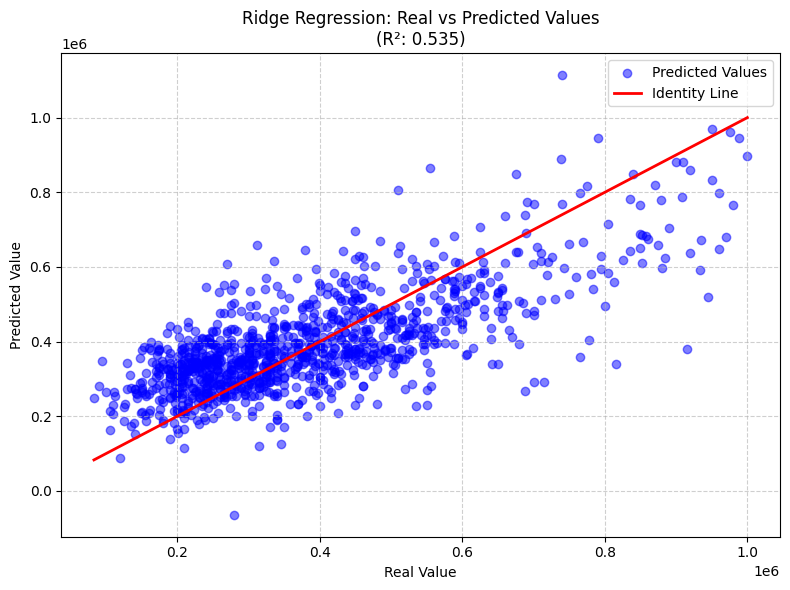

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred_ridge, color='blue', alpha=0.5, label='Predicted Values')

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', lw=2, label='Identity Line')

plt.title(f'Ridge Regression: Real vs Predicted Values\n(R²: {r2_score(Y_test, y_pred_ridge):.3f})')
plt.xlabel('Real Value')
plt.ylabel('Predicted Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [45]:
# Ridge coefficients
ridge_coefs = best_ridge_model.best_estimator_.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge_coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print(coef_df.to_string(index=False))

                   Feature   Coefficient
                     grado  82318.849537
       año_de_construcción -67736.426071
area_de_ construcción_pie2  54219.897422
              numero_baños  23081.496613
              numero_pisos  19040.583538
            numero_cuartos -15797.341354
                 condición   7423.385258
    superficie_sótano_pie2   4843.648327
        area_del lote_pie2   3198.621374


### 4.2 Lasso model

In [24]:
param_grid_lasso = {'lasso__alpha': [0.1, 0.25, 0.5]}

In [25]:
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

In [26]:
best_lasso_model = GridSearchCV(lasso_model, param_grid_lasso, cv=partitions, n_jobs=-1)
best_lasso_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': [0.1, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [35]:
print("Best parameter for Lasso: {}".format(best_lasso_model.best_params_)) 
# R^2
print("Best R²:", best_lasso_model.best_score_.round(4))

Best parameter for Lasso: {'lasso__alpha': 0.5}
Best R²: 0.5004


Evaluation of the model against the test data

In [30]:
y_pred_lasso = best_lasso_model.predict(X_test)

print(f"MSE: {mean_squared_error(Y_test, y_pred_lasso):.2f}")
print(f"MAE: {mean_absolute_error(Y_test, y_pred_lasso):.2f}")
print(f"R²: {r2_score(Y_test, y_pred_lasso):.2f}")

MSE: 14565133711.76
MAE: 95101.00
R²: 0.54


#### Predictions vs Real values

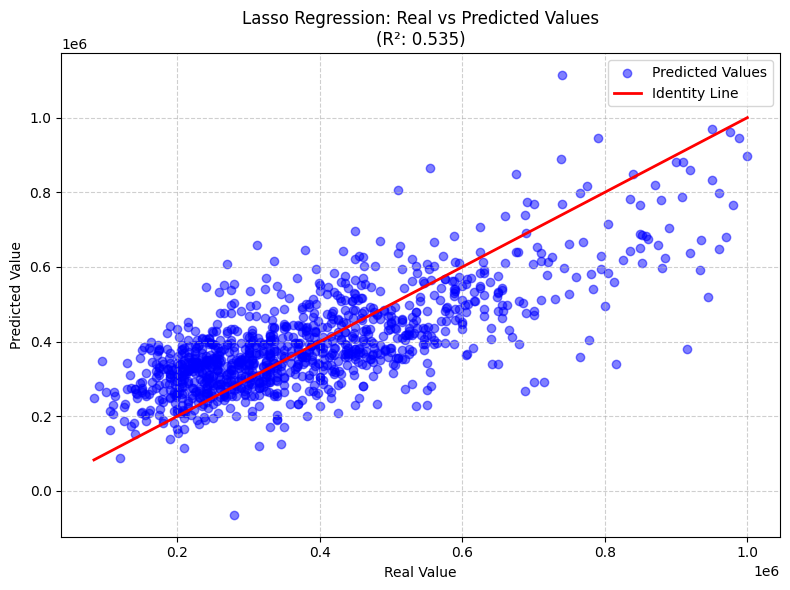

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred_lasso, color='blue', alpha=0.5, label='Predicted Values')

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', lw=2, label='Identity Line')

plt.title(f'Lasso Regression: Real vs Predicted Values\n(R²: {r2_score(Y_test, y_pred_lasso):.3f})')
plt.xlabel('Real Value')
plt.ylabel('Predicted Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [44]:
# Lasso coefficients
lasso_coefs = best_lasso_model.best_estimator_.named_steps['lasso'].coef_
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print(coef_df.to_string(index=False))

                   Feature   Coefficient
                     grado  82332.152644
       año_de_construcción -67752.156595
area_de_ construcción_pie2  54230.537927
              numero_baños  23083.684725
              numero_pisos  19038.628529
            numero_cuartos -15804.196741
                 condición   7422.754136
    superficie_sótano_pie2   4836.463664
        area_del lote_pie2   3196.989776


## ASUM-DM Phase 8: Evaluation

# 5. Conclusions

### Model Performance Comparison

| Metric | Ridge | Lasso |
|--------|-------|-------|
| Best α | 0.5 | 0.5 |
| Test R² | 0.54 | 0.54 |
| Test MAE | 95,100.68 | 95,101.00 |

### Ridge vs Lasso Coefficients

| Feature | Ridge | Lasso | Difference |
|---------|-------|-------|------------|
| grado | 82,318.85 | 82,332.15 | -13.30 |
| año_de_construcción | -67,736.43 | -67,752.16 | +15.73 |
| area_de_construcción_pie2 | 54,219.90 | 54,230.54 | -10.64 |
| numero_baños | 23,081.50 | 23,083.68 | -2.18 |
| numero_pisos | 19,040.58 | 19,038.63 | +1.95 |
| numero_cuartos | -15,797.34 | -15,804.20 | +6.86 |
| condición | 7,423.39 | 7,422.75 | +0.64 |
| superficie_sótano_pie2 | 4,843.65 | 4,836.46 | +7.19 |
| area_del_lote_pie2 | 3,198.62 | 3,196.99 | +1.63 |

### Key Findings

1. Both models achieved R² = 0.54, with virtually no difference in MAE.

2. Ridge and Lasso produced nearly the same coefficients.

3. Lasso did not eliminate any variables at α = 0.5. All 9 features contribute to the model.

4. Feature importance ranking (highest to lowest impact):
   - `grado` (positive) — strongest impact
   - `año_de_construcción` (negative) — older properties cost more
   - `area_de_construcción_pie2` (positive)
   - `numero_baños` (positive)
   - `numero_pisos` (positive)
   - `numero_cuartos` (negative) — fewer rooms = higher price
   - `condición` (positive)
   - `superficie_sótano_pie2` (positive)
   - `area_del_lote_pie2` (positive) — weakest impact

Ridge and Lasso perform identically. The most influential feature is `grado`.